# 📘 Introducción a Minería de Datos

Minería de Datos es el proceso de descubrir patrones, tendencias y conocimiento útil a partir de grandes volúmenes de datos.

🎯 En este notebook vamos a ver:

- Porque usar Jupyter Notebook 📝
- Algunas librerías de Python para análisis de datos 📊
- Cómo explorar y preparar un dataset real 🔎

# 🛠️ Herramientas principales

## 📒 Jupyter Notebook
Vamos a trabajar con código de python en **Cuadernos de Jupyter** (Jupyter notebook's) . El [**Proyecto Jupyter**](https://jupyter.org/) surge en 2014, como una librería de código abierto y sin fines de lucro de soporte interactivo para ciencia de datos y computo científico en todos los lenguajes de programación. Estos documentos contienen texto, imágenes y fragmento de código ejecutable. El texto se formatea en el lenguaje [**Markdown**](https://markdown.es/), un código de texto plano, simple y fácil de escribir.

## ☁️ Google Colab
Una forma fácil y rápida de empezar es ejecutar los cuadernos, es con **Google Colab**: un servicio gratuito que permite ejecutar cualquier cuaderno Jupyter directamente en línea, sin necesidad de instalar nada en el equipo. Solo se necesita un navegador web y una cuenta de Google. Por lo tanto sugerimos que utilicen esa plataforma, pero pueden utilizar el entorno de desarrollo (IDE) que les quede mas cómodo, ya sean otras plataformas o de manera local con Visual Studio Code por ejemplo.

## 📚 Scikit-Learn
[Scikit-Learn](https://scikit-learn.org) es una biblioteca de Python ampliamente utilizada para implementar algoritmos de aprendizaje automático de manera práctica y eficiente. Su diseño intuitivo y su extensa documentación, la convierten en un excelente punto de partida para quienes desean adentrarse en este campo. La librería fue creada por David Cournapeau en 2007 y, en la actualidad, es desarrollada y mantenida por un equipo de investigadores del Instituto Francés de Investigación en Ciencias de la Computación y Automatización (Inria).

## ✍️ PEP 8
Es la [guía de estilo](https://peps.python.org/pep-0008/) de Python 🐍 que recomienda buenas prácticas de programación:

- Nombres de variables claros

- Uso de espacios y tabulaciones consistentes

- Comentarios descriptivos

## 🔗 Pipelines en Scikit-Learn

En proyectos de **Minería de Datos** y **Aprendizaje automático**, es común tener que aplicar varios pasos de preprocesamiento antes de entrenar un modelo. Algunos ejemplos son: normalización, codificación de variables, selección de características, etc.

👉 En lugar de hacerlo manualmente paso por paso, Scikit-Learn ofrece la clase `Pipeline`, que permite **encadenar transformaciones y un estimador final** en un solo objeto.

💡 Esto es útil cuando tenemos que entrenar varios clasificadores y queremos garantizar **reproducibilidad**, o para combinar diferentes pipelines de preprocesamiento con diferentes clasificadores.

## 📖 Bibliografía

Vamos a usar como referencia el libro:

> Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow (Aurélien Géron. O’Reilly Media, Inc. 3er  Edition. 2023) [Hands on Machine Learning Notebooks]

Todos los ejemplos prácticos del libro los encuentran en el repositorio de GitHub: (https://colab.research.google.com/github/ageron/handson-ml3/blob/main/index.ipynb#scrollTo=HtTeqfRyvpgf)

# Lista de chequeo
Ejemplo de algunos pasos iniciales a tener en cuenta en un proyecto de **Minería de Datos**:

1. Definición del objetivo
2. Adquisición de datos
3. Examinar estructura
4. Separación del conjunto de prueba
5. Análisis exploratorio
6. Preparación de los datos:
    - Limpieza
    - Escalado
    - Discretización
7. Aplicación del modelo

<img src="https://davidrsch.github.io/r4ds-es/diagrams/data-science/base.png" width="600">

## 1. 🎯 Objetivo
Entender cuales son los pasos necesarios en un proyecto de Minería de Datos.

# 📦 Configuración

In [ ]:
!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler

# 2. 📂 Adquisición de datos
### Descripción
Los datos de la **Encuesta de Presupuestos Familiares** (EPF) de 2006 en España presentan los gastos medios por persona de las familias españolas para las 19 comunidades autónomas en 12 variables:

  - **X1** = Alimentos y bebidas no alcohólicas
  - **X2** = Bebidas alcohólicas y tabaco
  - **X3** = Vestido y calzado
  - **X4** = Vivienda, agua, electricidad, gas y otros combustibles
  - **X5** = Muebles, artículos del hogar y artículos para el mantenimiento corriente del hogar
  - **X6** = Sanidad
  - **X7** = Transporte
  - **X8** = Comunicaciones
  - **X9** = Ocio y cultura
  - **X10** = Enseñanza
  - **X11** = Restaurantes y hoteles
  - **X12** = Otros bienes y servicios

Fuente: Servicio de atención estadístico. Instituto de Estadística de la Comunidad de Madrid (IECM). (https://iestadis.edatos.io/statistical-visualizer/visualizer/data.html?resourceType=dataset&agencyId=IECM&resourceId=127_000032&version=~latest#visualization/table)

In [ ]:
!gdown 1j04WQ-ysIh_7LHJjnRHVMzLTwMKA_E07

Downloading...
From: https://drive.google.com/uc?id=1j04WQ-ysIh_7LHJjnRHVMzLTwMKA_E07
To: /content/dataset-IECM.xlsx
100% 54.1k/54.1k [00:00<00:00, 70.1MB/s]


In [ ]:
df = pd.read_excel("/content/dataset-IECM.xlsx")

## 3. 📊 Estructura
Observar las variables y algunas filas de datos.

In [ ]:
df.head()

,Comunidad,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
0,Madrid,4696.7,471.4,1238.4,12627.0,1548.2,1477.2,3471.6,1044.8,1572.8,734.6,2798.9,2644.8
1,Andalusia,4719.5,568.3,1072.7,8267.9,1308.8,1058.9,3329.6,873.7,1154.8,243.8,2344.0,2023.3
2,Aragon,5080.6,524.5,1134.8,9623.0,1324.0,1231.6,2617.2,940.6,1254.8,456.0,2279.2,2161.1
3,Asturias,4596.1,517.4,1242.5,8622.2,1170.6,1066.4,2741.3,902.9,1015.5,244.2,1923.4,2050.2
4,Balearic Islands,5036.0,488.1,988.6,11523.1,1108.7,1150.2,3730.5,1130.6,1352.8,312.0,2137.0,2219.7


Información general: cantidad de filas (muestras), tipos de atributos, cantidad de valores no nulos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Comunidad  19 non-null     object 
 1   X1         19 non-null     float64
 2   X2         19 non-null     float64
 3   X3         19 non-null     float64
 4   X4         19 non-null     float64
 5   X5         19 non-null     float64
 6   X6         19 non-null     float64
 7   X7         19 non-null     float64
 8   X8         19 non-null     float64
 9   X9         19 non-null     float64
 10  X10        17 non-null     float64
 11  X11        19 non-null     float64
 12  X12        19 non-null     float64
dtypes: float64(12), object(1)
memory usage: 2.1+ KB


Si tengo variables categóricas, puedo observar cuales son y cuantas muestras de cada tengo.

In [ ]:
df['Comunidad'].value_counts()

,count
Comunidad,
Madrid,1
Andalusia,1
Aragon,1
Asturias,1
Balearic Islands,1
Canary Islands,1
Cantabria,1
Castile and Leon,1
Castile-La Mancha,1


Puedo tener un resumen de cada una de las variables numéricas: cantidad de muestras, media, desvio estandar, percentiles, valores mínimos y valores máximos.

In [ ]:
df.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
count,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,19.000000,17.000000,19.000000,19.000000
mean,4768.063158,474.831579,1201.378947,9422.947368,1283.378947,1183.984211,3113.763158,933.936842,1243.784211,371.317647,2214.163158,2164.226316
std,345.916236,62.395442,198.185406,1580.342853,218.596151,196.678546,323.104615,98.732046,231.496197,184.393557,397.852283,305.589805
min,4325.500000,370.900000,908.500000,7210.100000,960.600000,865.300000,2617.200000,794.500000,847.300000,177.000000,1542.100000,1609.000000
25%,4503.250000,436.950000,1084.000000,8417.300000,1130.200000,1056.600000,2947.150000,851.550000,1074.700000,243.800000,2030.200000,1990.100000
50%,4696.700000,454.300000,1174.600000,8747.500000,1255.900000,1162.800000,3070.500000,902.900000,1199.300000,298.500000,2189.300000,2124.200000
75%,5058.300000,520.950000,1268.000000,10305.800000,1408.050000,1280.700000,3375.900000,1009.150000,1338.650000,456.000000,2344.150000,2235.800000
max,5542.000000,575.600000,1683.600000,12627.000000,1750.300000,1558.800000,3730.500000,1130.600000,1864.300000,734.600000,2965.900000,3010.700000


El **histograma** de los atributos númericos permite observar la distribución de los datos.

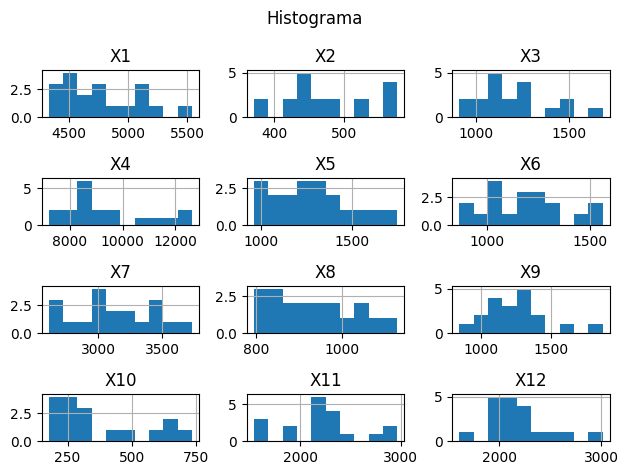

In [ ]:
df.hist()
plt.suptitle('Histograma')
plt.tight_layout()
plt.show()

Hasta acá hicimos un análisis para entender los tipos de datos. Para seeguir profundizando es necesario separar el conjunto de test para evitar sesgo de espionaje de los datos o *data snooping bias*.  

## 4. Conjunto de prueba
Este paso recien lo aplicamos para el segundo TP.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
# Creo un diccionario para mapear comunidades en regiones
region_map = {
    'Madrid': 'Central',
    'Andalusia': 'East',
    'Aragon': 'North',
    'Asturias': 'North',
    'Balearic Islands': 'East',
    'Canary Islands': 'East',
    'Cantabria': 'North',
    'Castile and Leon': 'Central',
    'Castile-La Mancha': 'Central',
    'Catalonia': 'North',
    'Valencia': 'East',
    'Extremadura': 'Central',
    'Galicia': 'North',
    'Murcia': 'East',
    'Navarre': 'North',
    'Basque Country': 'North',
    'La Rioja': 'North',
    'Ceuta': 'North',
    'Melilla': 'North'
}

# Creo un nuevo atributo Region
df['Region'] = df['Comunidad'].map(region_map)

display(df.head())

,Comunidad,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,Region
0,Madrid,4696.7,471.4,1238.4,12627.0,1548.2,1477.2,3471.6,1044.8,1572.8,734.6,2798.9,2644.8,Central
1,Andalusia,4719.5,568.3,1072.7,8267.9,1308.8,1058.9,3329.6,873.7,1154.8,243.8,2344.0,2023.3,East
2,Aragon,5080.6,524.5,1134.8,9623.0,1324.0,1231.6,2617.2,940.6,1254.8,456.0,2279.2,2161.1,North
3,Asturias,4596.1,517.4,1242.5,8622.2,1170.6,1066.4,2741.3,902.9,1015.5,244.2,1923.4,2050.2,North
4,Balearic Islands,5036.0,488.1,988.6,11523.1,1108.7,1150.2,3730.5,1130.6,1352.8,312.0,2137.0,2219.7,East


In [ ]:
df['Region'].value_counts()/len(df)

,count
Region,
North,0.526316
East,0.263158
Central,0.210526


In [ ]:
train, test = train_test_split(df, test_size=0.2, stratify=df['Region'], random_state=42)

In [ ]:
test['Region'].value_counts()/len(test)

,count
Region,
North,0.50
East,0.25
Central,0.25


In [ ]:
for data in (train, test):
  data.drop(columns='Region', inplace=True)
del data

In [ ]:
test

,Comunidad,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
5,Canary Islands,4467.0,433.8,908.5,8063.9,1099.7,865.3,3216.1,1039.2,1053.3,312.9,1663.8,1911.7
8,Castile-La Mancha,4366.8,370.9,968.9,8475.5,983.9,1011.4,3021.2,827.3,847.3,177.0,1631.3,1609.0
15,Basque Country,5171.4,478.3,1377.3,12165.4,1419.5,1128.1,3070.5,952.3,1314.2,643.3,2965.9,2358.9
6,Cantabria,4732.1,454.3,1095.3,9248.6,1221.4,1169.0,3089.9,840.4,1034.9,203.0,1542.1,2042.1


## 5. 🔎 Análisis exploratorio

Introducido por por el estadistico Tukey en 1977, en su libro *Exploratory Data Analysis*.

El objetivo es **comprender los datos** y para eso se realizan **preguntas**. Es un proceso **ciclico y creativo**, donde cada pregunta revela un aspecto nuevo de los datos y aumenta las posibilidades de hacer un **descubrimiento**.

No hay una regla sobre qué preguntas debe hacer, pero hay dos preguntas que suelen ser útiles:

1. ¿Qué tipo de variación ocurre dentro de las variables?
2. ¿Qué tipo de covariación ocurre entre las variables?


In [ ]:
epf = train.copy()

In [ ]:
X = epf.drop(columns='Comunidad')
y = epf['Comunidad']

Podemos observar la correlación entre atributos con el coeficiente de correlacion estandar o coeficiente de Pearson y mostralos en una matriz, conocida como matriz de correlación.

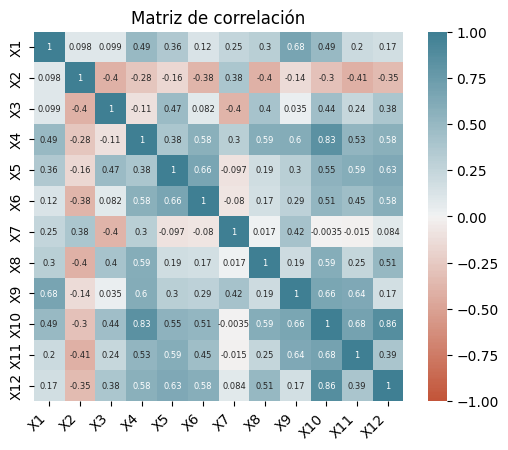

In [ ]:
corr = X.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

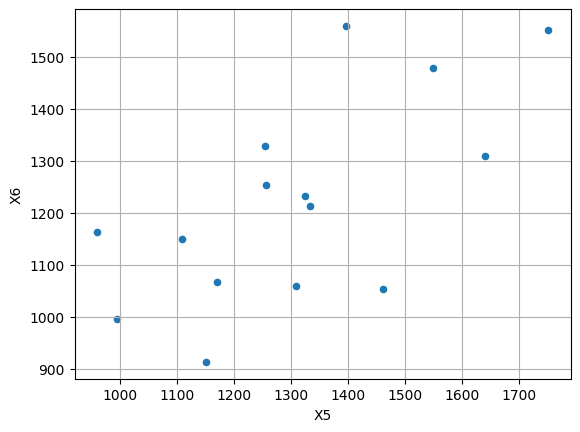

In [ ]:
X.plot(kind="scatter", y='X6', x="X5", grid=True)
plt.show()

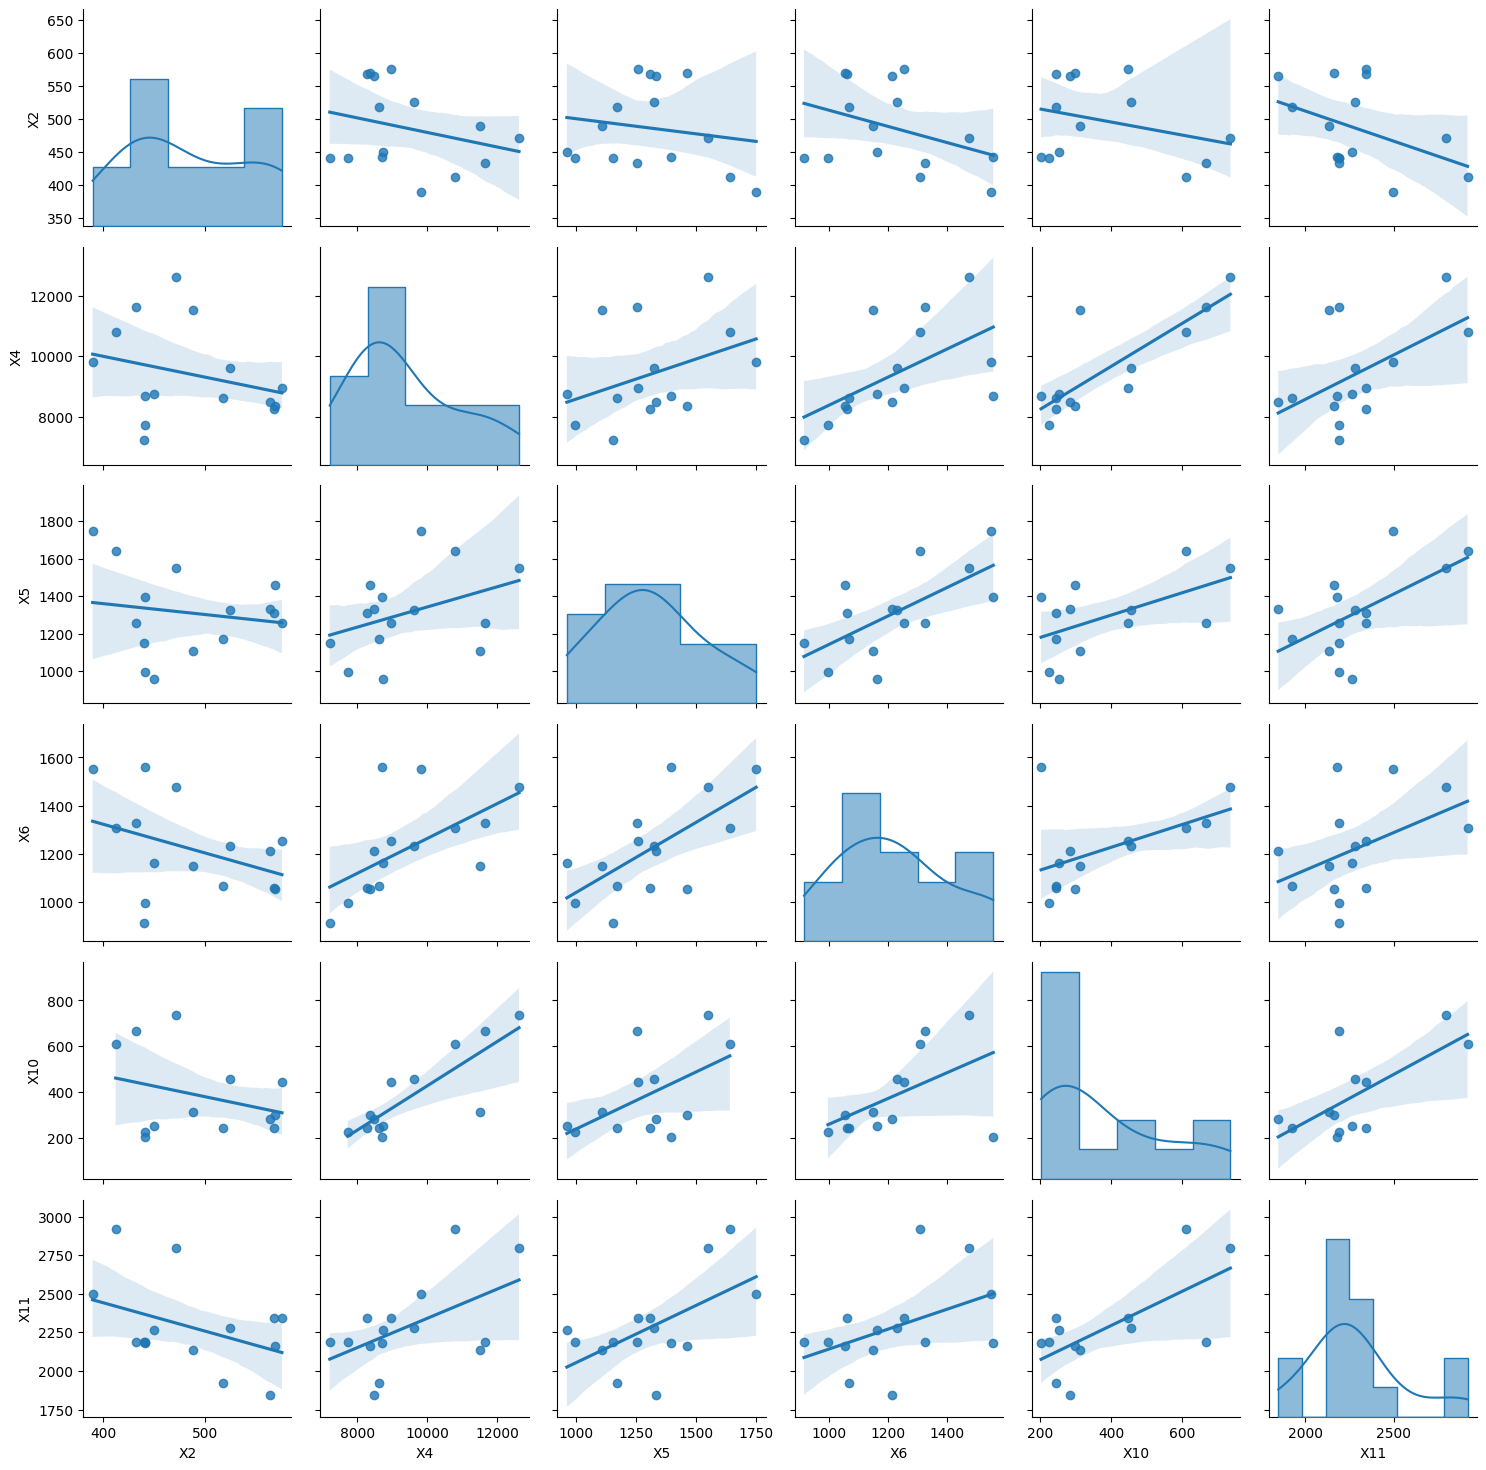

In [ ]:
subcols = ['X2', 'X4','X5', 'X6', 'X10', 'X11']
g = sns.PairGrid(X[subcols])
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

El coeficiente de correlación estandar solo mide correlaciones lineales entre atributos numéricos y no me brinda información sobre la pendiente de la correlación.



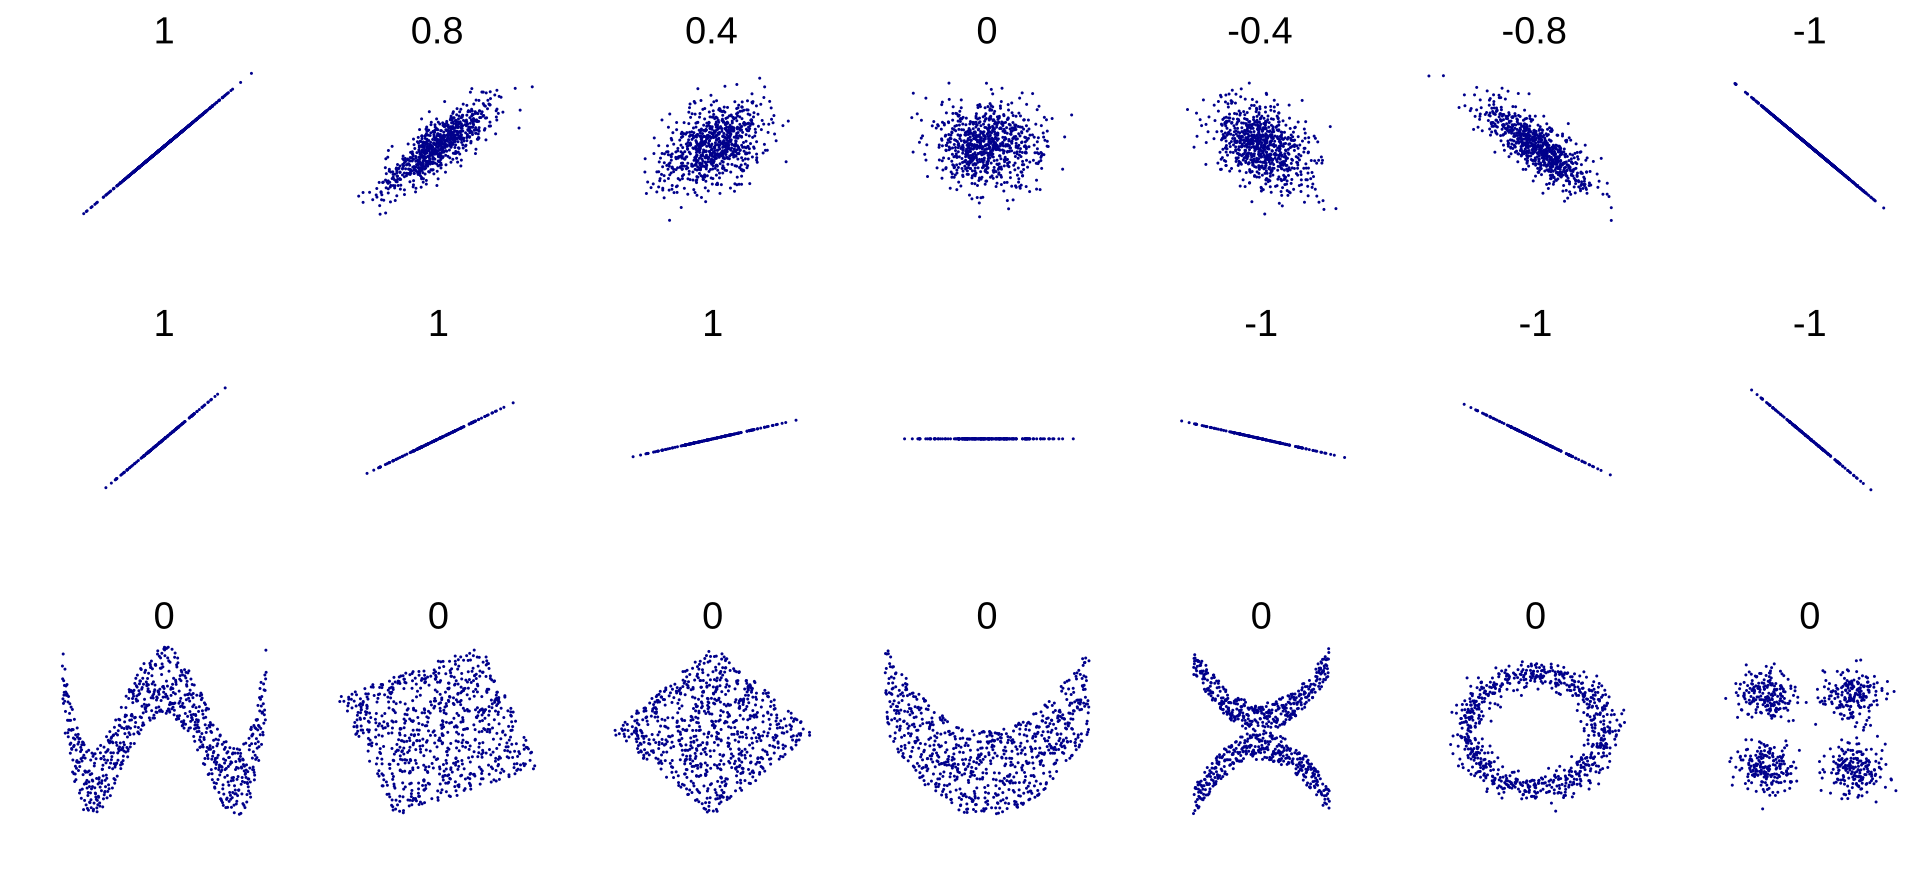

La matriz de **correlación** es importante realizarla con la **variable objetivo**, sobre todo cuando se realizan tareas de **regresión**, ya que una alta correlación indica relevancia en la tarea de regresión.

La correlación entre **variables descriptivas** indica que no son mutuamente independientes y que es posible **reducir la dimensionalidad** haciendo ingeniería de características o utilizando técnicas de reducción de la dimensionalidad.

## 6. 🔧 Preparación de los datos

### 🧹 Limpieza

#### Valores nulos

In [ ]:
X.isnull().sum()

,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,0
X9,0
X10,2


Muchos de los algoritmos no soportan valores nulos, por lo tanto podemos eliminar las muestras con valores nulos, eliminar el atributo con valores nulos o reemplazar los valores nulos con algún valor como la media. En Pandas DataFrame tenemos las funciones `drop()`, `dropna()` o `fillna()` para facilitar el cálculo.

In [ ]:
# X['X10'] = X['X10'].fillna(value=df['X10'].mean())
imputer = SimpleImputer(strategy = 'mean')
imputer.set_output(transform="pandas")
imputer.fit(X)
X = imputer.transform(X)

#### Valores atípcos
Remoción de valores atípicos (outliers)

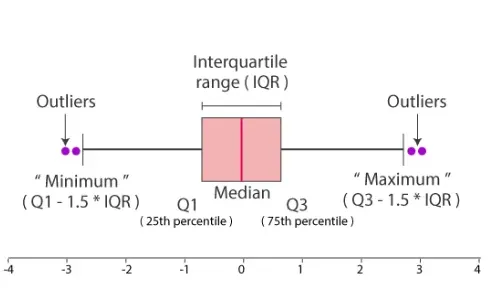

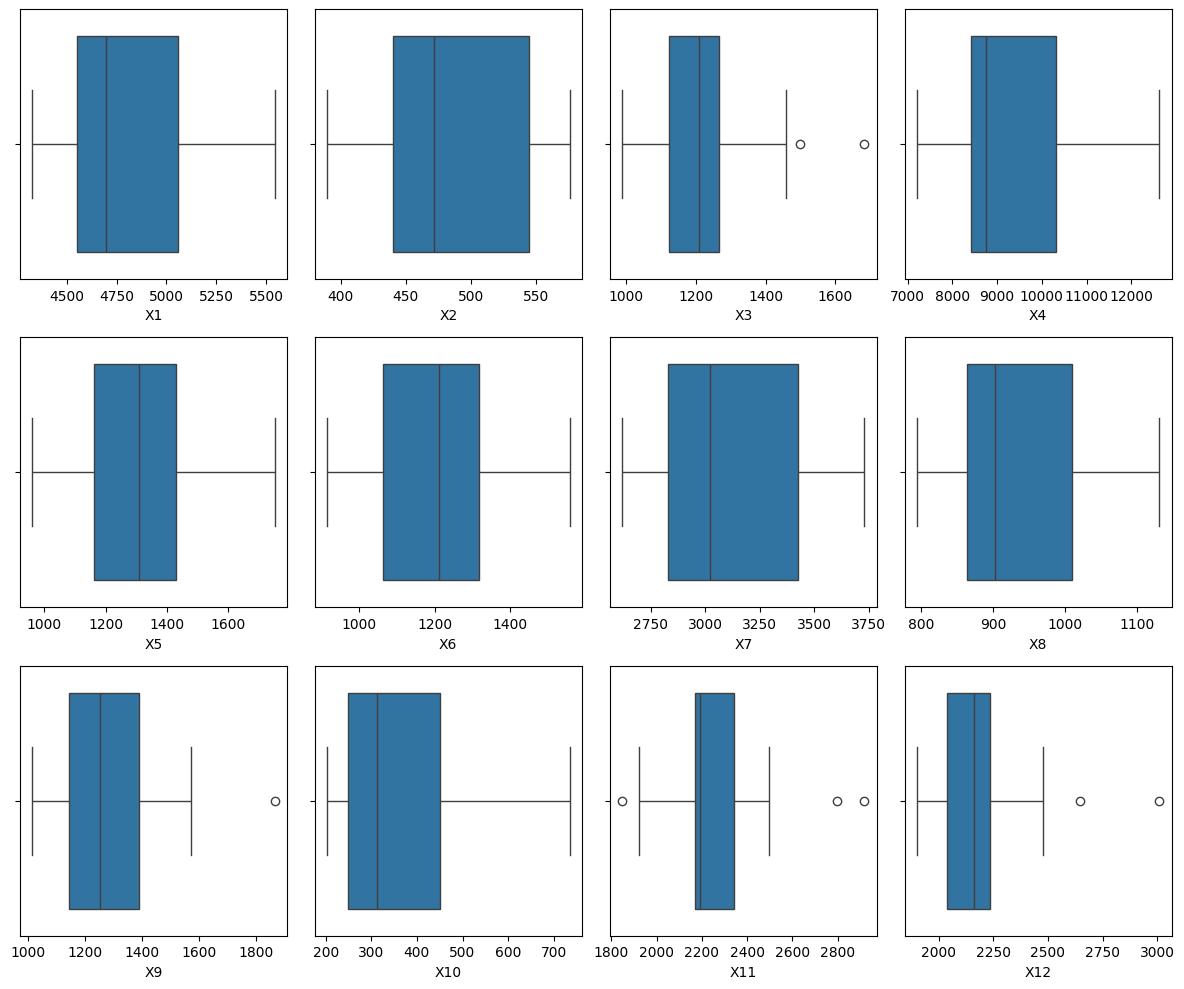

In [ ]:
cols = X.columns
fig, axes = plt.subplots(nrows=3, ncols=4, sharey=False,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.boxplot(data=X, x=col, ax=axes.flatten()[i-1])

plt.tight_layout()
plt.show()

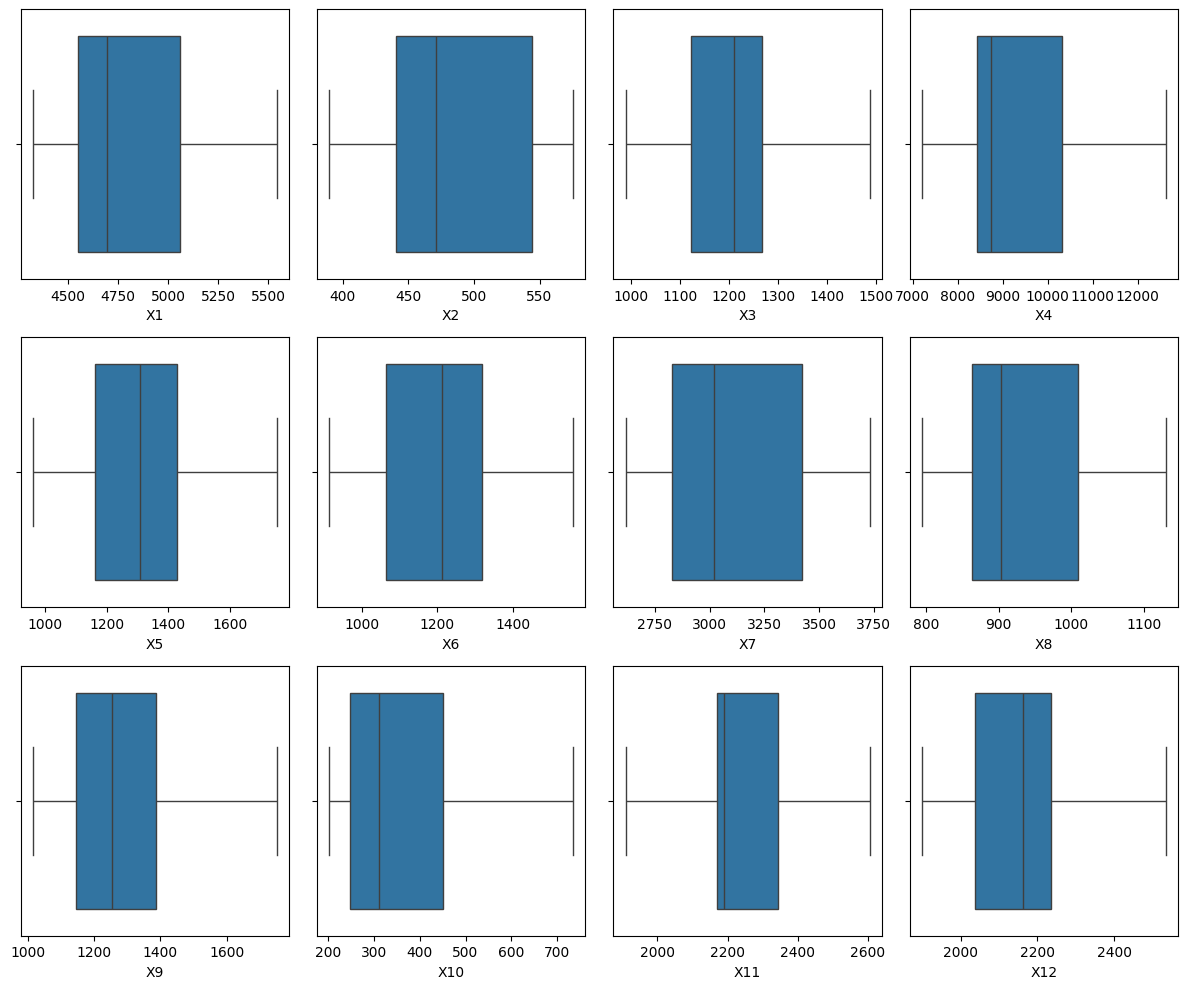

In [ ]:
clean = cols[[2, 8, 10, 11]]
X_clean = X.copy()
winsor = Winsorizer(capping_method='iqr', tail='both',fold=1.5)
X_clean[clean] = winsor.fit_transform(X_clean[clean])

fig, axes = plt.subplots(nrows=3, ncols=4, sharey=False,
                         figsize=(12, 10))
for i, col in enumerate(cols, 1):
    sns.boxplot(data=X_clean, x=col, ax=axes.flatten()[i-1])

plt.tight_layout()
plt.show()

### ⚖️ Escalado

En la mayoría de los casos, los algoritmos de Aprendizaje Automático funcionan mejor cuando los atributos tienen escalas similares. El escalado se realiza para evitar problemas con atributos de distinta naturaleza y variabilidad. Según el método que se utilice luego, es necesario o no estandarizar, ya  que los atributos con mayores valores de varianza quitarán peso al resto de los atributos.

In [ ]:
#X_std = (X_clean-X_clean.mean())/X_clean.std()
scaler = StandardScaler().set_output(transform="pandas")
X_std = scaler.fit_transform(X_clean)
X_std

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
9,1.046592,-0.877520,-0.055061,1.470366,-0.256089,0.557555,-0.282718,0.871588,0.196606,1.740556,-0.324178,1.540264
0,-0.275828,-0.234188,0.132837,2.119464,1.097178,1.347213,1.006024,1.081153,1.478921,2.157580,1.765117,1.830228
16,-1.095717,-0.727793,-0.277707,-0.468176,0.396989,1.777074,-1.287567,-0.608660,-0.975899,-1.103793,-0.373590,-1.392661
10,-0.665312,1.480266,-0.696616,-0.294157,-0.252856,0.167203,0.219991,-0.876495,0.204816,0.386455,0.451792,0.016139
3,-0.571989,0.522673,0.159220,-0.515348,-0.646828,-0.816841,-1.069319,-0.369449,-1.380759,-0.849899,-1.670402,-0.629582
14,2.212689,-1.208235,1.549148,0.911798,1.523481,0.456938,-0.397525,0.435078,2.392680,1.385473,1.765117,-0.006215
4,0.723053,0.040585,-1.474589,1.393193,-0.932723,-0.375391,1.741757,1.958261,0.350032,-0.434101,-0.593423,0.231548
7,-0.738616,-0.584647,-0.510005,-0.432911,-1.616747,-0.309015,0.865640,-0.912274,0.715382,-0.795318,0.064059,-1.103585
18,-0.995917,-0.749182,1.731093,-1.444388,-0.734121,-1.621250,-1.335593,1.572865,-1.178072,0.000000,-0.329724,-0.253631
17,-0.552853,-1.580084,1.731093,0.272832,2.030609,1.736511,-0.571157,0.561840,-0.748581,0.000000,1.218686,1.830228
